# Google 多元化聚類分析 — GAMMA_DNA v2 解法 (`gamma_sol_v2`)

**任務**：重現 `datasets/diversity_clustering.ipynb` 的六個業務問題，**僅使用 `GAMMA_DNA`（v2）**。

**資料**：`datasets/dataset-google.csv`

| 能力 | GAMMA_DNA v2 API |
|------|------------------|
| Local data warehouse | `g.frames` / `g.warehouse.ingest` / `g.warehouse.persist()` |
| Data lineage | `g.pipe().run()` / `g.lineage` / `g.visualize()` / `g.warehouse.catalog()` |
| 聚類 + PCA | `g.insights.segment()` → `report.plot_embedding()` / `preview()` / `commit()` |
| 層次聚類熱圖 | `g.pivot_heatmap(..., cluster=True)`（Ward 重排） |
| 降維 / 結構 | `g.eda.redundancy()` + `g.viz.pairplot()` |
| 分布偏移（2021→2023） | `g.prep.variate_shift()` |
| 失衡 / 公平性 | `g.prep.data_bias_check()` |

## 分析問題
1. 哪些行業在性別與種族方面有相似的人口結構？
2. 哪三個行業的性別比例最不平衡？與勞動力總規模有何關係？
3. 2021–2023 年間，哪三個產業的勞動力多元變化最為顯著？
4. 哪些行業由單一族群主導？不平衡程度有多嚴重？
5. 哪些產業的種族多樣性最高？與產業規模有何關係？
6. 能否根據相似的種族組成對產業進行分組？


## 0. 環境設定


In [1]:
import sys
import os
from pathlib import Path

# Resolve GAMMA_ROOT relative to notebook location (analytics-gym/google → analytics-gym → DAPS_Brix)
GAMMA_ROOT = Path(os.getcwd()).parent.parent
if not (GAMMA_ROOT / "gamma").exists():
    # Fallback: walk up from cwd until we find the gamma package
    _p = Path(os.getcwd())
    while _p != _p.parent:
        if (_p / "gamma").exists():
            GAMMA_ROOT = _p
            break
        _p = _p.parent

if str(GAMMA_ROOT) not in sys.path:
    sys.path.insert(0, str(GAMMA_ROOT))

from gamma import GAMMA_DNA
from gamma.data_exploration import gamma_de_load_files
from gamma.qb_theme import apply_qb_theme
from IPython.display import display

apply_qb_theme()

DATA_PATH = Path("datasets/dataset-google.csv")
WAREHOUSE = Path(".warehouse/google")
WAREHOUSE.mkdir(parents=True, exist_ok=True)

DEMO_COLS = [
    "percent_women",
    "percent_white",
    "percent_black_or_african_american",
    "percent_asian",
    "percent_hispanic_or_latino",
]
RACE_COLS = DEMO_COLS[1:]
MIN_EMP_CLUSTER = 50
MIN_EMP_RANK = 100
N_SEGMENTS = 4
RACE_SEGMENTS = 4


──────────────────────────────────────────────────────────────
  QB Theme ·  mode=DARK  ·  bg=#111424  ·  accent=#02A9F4
──────────────────────────────────────────────────────────────
  Categorical                          
  Sequential    qb_sequential  /  qb_sequential_r
  Diverging     qb_diverging   /  qb_diverging_r
  Plotly        pio.templates.default = 'qb_dark'
  Reset Plotly  pio.templates.default = 'plotly'
  Reset MPL     import matplotlib as mpl; mpl.rcdefaults()
──────────────────────────────────────────────────────────────



## 1. 載入資料 → 初始化 Session

以 `gender_imbalance` 作為 placeholder target（本題為無監督結構分析，不訓練監督模型）。


In [2]:
raw = gamma_de_load_files(str(DATA_PATH.resolve()))
print(f"Rows={len(raw):,}")

g = GAMMA_DNA(raw, target="gender_imbalance", task="regression", name="google_diversity")
g.skim()


Rows=1,272


,variable,dtype,n,n_missing,pct_missing,n_unique,mean,std,se,min,p25,median,p75,max,skew,kurtosis,top,top_freq
0,year,float64,1271,1,0.08,4,2021.5004,1.1188,0.0314,2020.000,2020.50000,2022.0000,2022.50000,2023.0,-0.0010,-1.3608,NaN,NaN
1,sector,str,1271,1,0.08,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Manufacturing,387.0
2,subsector,str,1215,57,4.48,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Durable goods manufacturing,212.0
3,industry_group,str,1015,257,20.20,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Primary metals and fabricated metal products m...,52.0
4,industry,str,507,765,60.14,127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Traveler accommodation,4.0
5,total_employed_in_thousands,float64,1269,3,0.24,798,2040.9827,9370.4733,263.0454,0.000,99.00000,321.0000,1124.00000,161037.0,14.0150,222.9163,NaN,NaN
6,percent_women,float64,1132,140,11.01,533,0.4299,0.4807,0.0143,0.030,0.25775,0.3835,0.54000,10.9,18.0320,387.8123,NaN,NaN
7,percent_white,float64,1132,140,11.01,302,0.9451,3.7766,0.1122,0.040,0.73600,0.7920,0.84125,93.7,23.7536,563.1711,NaN,NaN
8,percent_black_or_african_american,float64,1132,140,11.01,249,0.1236,0.2265,0.0067,0.000,0.07500,0.1050,0.14400,6.7,24.3356,664.5615,NaN,NaN
9,percent_asian,float64,1132,140,11.01,182,0.0653,0.0735,0.0022,0.000,0.03300,0.0540,0.07800,1.7,11.3465,223.3741,NaN,NaN


## 2. Pipeline + Local Data Warehouse

以 **`g.pipe().run()`** 建立多 stage 資料血緣；各 stage 登記至 **`g.frames`**。結束時以 **`g.warehouse.persist()`** 寫入 local medallion warehouse（parquet + manifest）。

設計決策與 sklearn 版一致：比例 0–1/0–100 統一、建立 `entity_path`、2023 橫截面快照、衍生 HHI / diversity 指標。


In [3]:
import pandas as pd
import numpy as np


def prep_entities(df):
    out = df.copy()
    demo = out[DEMO_COLS].apply(pd.to_numeric, errors="coerce")
    needs_scale = demo.gt(1).any(axis=1)
    scaled = demo.copy()
    scaled.loc[needs_scale] = demo.loc[needs_scale] / 100.0
    out[DEMO_COLS] = scaled

    def finest_label(row):
        for col in ["industry", "industry_group", "subsector", "sector"]:
            val = row.get(col)
            if pd.notna(val) and str(val).strip():
                return str(val).strip()
        return "Unknown"

    def hierarchy_path(row):
        parts = []
        for col in ["sector", "subsector", "industry_group", "industry"]:
            val = row.get(col)
            parts.append(str(val).strip() if pd.notna(val) and str(val).strip() else "")
        return " > ".join(parts)

    out["entity_label"] = out.apply(finest_label, axis=1)
    out["entity_path"] = out.apply(hierarchy_path, axis=1)
    out["total_employed_in_thousands"] = pd.to_numeric(
        out["total_employed_in_thousands"], errors="coerce"
    )
    out = out[~out["entity_label"].str.contains("Total, 16 years", na=False)].copy()
    out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")
    return out


def add_derived_metrics(df):
    out = df.copy()
    race = out[RACE_COLS].astype(float)
    race_sum = race.sum(axis=1).replace(0, np.nan)
    race_norm = race.div(race_sum, axis=0)
    out["gender_imbalance"] = (out["percent_women"] - 0.5).abs()
    out["race_hhi"] = (race_norm ** 2).sum(axis=1)
    out["race_diversity"] = 1 - out["race_hhi"]
    for col in RACE_COLS:
        out[f"{col}_norm"] = race_norm[col]
    return out


def snapshot_2023(df):
    latest = df[df["year"] == df["year"].max()].copy()
    return latest.drop_duplicates(subset="entity_path").copy()


(g.pipe("prepared", prep_entities)
   .pipe("featured", add_derived_metrics)
   .pipe("snapshot_2023", snapshot_2023)
   .run(from_stage="raw"))

g.use("snapshot_2023")
print(f"2023 分析快照：{len(g.df):,} 個實體")
display(g.frames_summary())
g.visualize()


2023 分析快照：317 個實體


,key,rows,cols,features,has_target
0,raw,1272,11,11,False
1,prepared,1268,13,13,False
2,featured,1268,20,19,True
3,snapshot_2023,317,20,19,True


## 3. 探索性分析（EDA + 失衡檢查）


In [4]:
g.use("snapshot_2023")
eda = g.eda(segment_cols=["sector"])
eda.summary()
display(eda.top_signals())

g.viz.scatter("total_employed_in_thousands", "gender_imbalance")
g.viz.scatter("total_employed_in_thousands", "race_diversity")
g.correlation_heatmap()

bias = g.prep.data_bias_check(protected_cols=["sector"], alpha=0.05)
bias.summary()


🔍 Running EDA pipeline...
  [1/5] Inspecting structure...
  [2/5] Inspecting quality...
  [3/5] Analysing missingness...
  [4/5] Analysing feature → 'gender_imbalance' relationships...
  [5/5] Analysing redundancy...
✅ EDA complete.


  Structure Report
  Rows              : 317
  Columns           : 20
  Memory            : 0.20 MB

  Numeric           : 14 cols  ['year', 'total_employed_in_thousands', 'percent_women', 'percent_white', 'percent_black_or_african_american', 'percent_asian']...
  Categorical       : 6 cols  ['sector', 'subsector', 'industry_group', 'industry', 'entity_label', 'entity_path']

  ⚠ Constant cols   : ['year']
  ⚠ High-cardinality: ['subsector', 'industry_group', 'industry', 'entity_label', 'entity_path']
  ⚠ Potential IDs   : ['entity_label', 'entity_path']

  Warnings:
    • 1 constant column(s) detected: ['year']
    • Potential ID columns (consider excluding from analysis): ['entity_label', 'entity_path']

  Data Quality Report
  Duplicate rows     : 0
  

,feature,signal_score,relationship_strength,monotonicity_score,lift_max,interpretation
0,percent_women,63.66,1.0000,0.667,1.962,Feature `percent_women` shows a strong negativ...
1,percent_asian_norm,49.74,0.2214,1.000,1.464,Feature `percent_asian_norm` shows a moderate ...
2,percent_asian,44.46,0.2285,0.889,1.468,Feature `percent_asian` shows a moderate negat...
3,percent_white_norm,35.32,0.1665,0.778,1.255,Feature `percent_white_norm` shows a moderate ...
4,race_diversity,32.34,0.2082,0.667,1.255,Feature `race_diversity` shows a moderate nega...
5,race_hhi,32.34,0.2082,0.667,1.255,Feature `race_hhi` shows a moderate positive b...
6,percent_black_or_african_american_norm,30.27,0.1598,0.667,1.365,Feature `percent_black_or_african_american_nor...
7,percent_white,28.01,0.2327,0.556,1.476,Feature `percent_white` shows a moderate posit...
8,percent_hispanic_or_latino,24.56,0.0397,0.667,1.139,Feature `percent_hispanic_or_latino` shows a w...
9,total_employed_in_thousands,24.04,0.1232,0.556,1.289,Feature `total_employed_in_thousands` shows a ...



  Data Bias Report
  Target column      : gender_imbalance
  Task               : regression
  Protected columns  : ['sector']
  Significance level : 0.05
  Bias index cutoff  : 0.8 (4/5 rule)

  11 group(s) flagged across all protected attributes.

  [sector]  test=anova  reference='Manufacturing'
                                      group  n  mean_target  positive_rate test_type   stat  p_value  bias_index  flag
Agriculture, forestry, fishing, and hunting  6       0.2185            NaN     anova 8.8248      0.0         NaN  True
              Education and health services 26       0.2430            NaN     anova 8.8248      0.0         NaN  True
                       Financial activities 17       0.1030            NaN     anova 8.8248      0.0         NaN  True
                                Information 11       0.1525            NaN     anova 8.8248      0.0         NaN  True
                    Leisure and hospitality 15       0.0632            NaN     anova 8.8248      0.0    

## 4. 聚類 + PCA（`g.insights.segment`）

特徵：女性比例 + 種族 normalized shares；僅保留就業 ≥ 50k 的實體。

`g.insights.segment()` 從 **stage registry** 讀取資料（不傳 `df=`），內建 StandardScaler + KMeans、Silhouette 選 k、PCA embedding。以 **`preview()` / `commit()`** 將 cluster 標籤寫回 lineage（`source="insights"`）。



  Insight Segments (kmeans, k=4)
  Features: ['percent_women', 'percent_white_norm', 'percent_black_or_african_american_norm', 'percent_asian_norm', 'percent_hispanic_or_latino_norm']
  Entities: 282

  Segment Profile: kmeans_cluster
  Segments: ['0', '1', '2', '3']
  N per segment:
    2                     n=111  (39.4%)
    1                     n=91  (32.3%)
    3                     n=68  (24.1%)
    0                     n=12  (4.3%)

  Highest on each metric:
    percent_women              → 2                     (0.5169)
    percent_white_norm         → 1                     (0.7506)
    percent_black_or_african_american_norm  → 3                     (0.1551)
    percent_asian_norm         → 0                     (0.2107)
    percent_hispanic_or_latino_norm  → 3                     (0.2058)


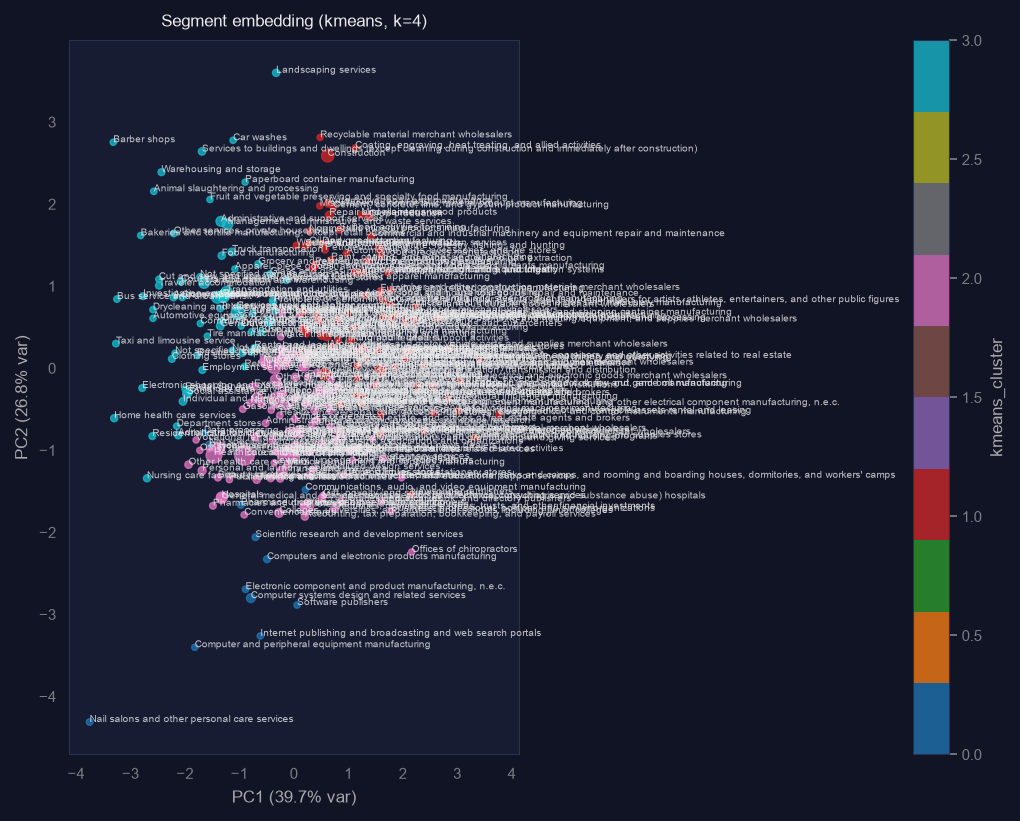

In [5]:
g.use("snapshot_2023")
cluster_base = g.df[g.df["total_employed_in_thousands"] >= MIN_EMP_CLUSTER].copy()
g.snapshot("cluster_base", cluster_base, from_stage="snapshot_2023")
g.use("cluster_base")

CLUSTER_FEATURES = ["percent_women"] + [f"{c}_norm" for c in RACE_COLS]

report = g.insights.segment(
    from_stage="cluster_base",
    features=CLUSTER_FEATURES,
    id_col="entity_path",
    method="kmeans",
    k=N_SEGMENTS,
)
report.summary()
report.plot_silhouette()
report.plot_radar()
report.plot_heatmap()
report.plot_embedding(
    size_col="total_employed_in_thousands",
    label_col="entity_label",
)

report.preview(g, from_stage="cluster_base")
report.commit(g, frame_key="clustered", from_stage="cluster_base")
g.use("clustered")


### 4.1 Ward 層次聚類熱圖（`g.pivot_heatmap`, `cluster=True`）


In [6]:
top25 = g.df.nlargest(25, "total_employed_in_thousands").copy()
g.snapshot("top25", top25, from_stage="clustered")

# melt 成 long format 供 pivot heatmap
melted = top25.melt(
    id_vars=["entity_label"],
    value_vars=CLUSTER_FEATURES,
    var_name="feature",
    value_name="share",
)
g.snapshot("top25_long", melted, from_stage="top25")

g_m = GAMMA_DNA(melted, target="share", task="regression", name="heatmap")
g_m.pivot_heatmap(
    index_var="entity_label",
    col_var="feature",
    val_var="share",
    aggfunc="mean",
    zscore=True,
    cluster=True,
)


feature,percent_asian_norm,percent_black_or_african_american_norm,percent_hispanic_or_latino_norm,percent_white_norm,percent_women
entity_label,,,,,
Accommodation and food services,0.064988,0.103981,0.235581,0.595451,0.530
Construction,0.013087,0.051578,0.261740,0.673595,0.108
Durable goods manufacturing,0.070796,0.084956,0.141593,0.702655,0.258
Education and health services,0.061538,0.140271,0.126697,0.671493,0.744
Educational services,0.055505,0.108280,0.117379,0.718835,0.689
Elementary and secondary schools,0.031475,0.108813,0.126799,0.732914,0.746
Finance and insurance,0.087993,0.115490,0.107241,0.689276,0.528
Financial activities,0.079091,0.109091,0.116364,0.695455,0.511
Food services and drinking places,0.063518,0.100163,0.234528,0.601792,0.523


## 5. 結構探索（redundancy + pairplot）


In [7]:
g.use("clustered")
g.viz.pairplot(DEMO_COLS + ["total_employed_in_thousands"], hue="kmeans_cluster")
red = g.eda.redundancy(threshold=0.85)
red.summary()



  Redundancy Report
  Numeric features analysed : 14
  High-corr pairs (|r|≥0.8) : 9
                        feature_1                              feature_2    corr  abs_corr
                         race_hhi                         race_diversity -1.0000    1.0000
                    percent_asian                     percent_asian_norm  0.9966    0.9966
       percent_hispanic_or_latino        percent_hispanic_or_latino_norm  0.9945    0.9945
percent_black_or_african_american percent_black_or_african_american_norm  0.9902    0.9902
                         race_hhi                     percent_white_norm  0.9821    0.9821
                   race_diversity                     percent_white_norm -0.9821    0.9821
                    percent_white                               race_hhi  0.8678    0.8678
                    percent_white                         race_diversity -0.8678    0.8678
                    percent_white                     percent_white_norm  0.8577    0.8577

  F

## 6. 業務問題回答


### Q1 & Q6：相似人口結構 / 種族分組


In [8]:
g.use("clustered")

q1_rows = []
for cid, grp in g.df.groupby("kmeans_cluster"):
    top = grp.nlargest(5, "total_employed_in_thousands")
    q1_rows.append({
        "cluster": cid,
        "n_entities": len(grp),
        "avg_women": grp["percent_women"].mean(),
        "avg_white": grp["percent_white"].mean(),
        "avg_black": grp["percent_black_or_african_american"].mean(),
        "avg_asian": grp["percent_asian"].mean(),
        "avg_hispanic": grp["percent_hispanic_or_latino"].mean(),
        "top_entities": ", ".join(top["entity_label"].tolist()),
    })
q1 = pd.DataFrame(q1_rows).round(3)
print("Q1：KMeans 集群輪廓（性別 + 種族）")
display(q1)

# Q6：僅種族特徵重新 segment
g.use("snapshot_2023")
rank_base = g.df[g.df["total_employed_in_thousands"] >= MIN_EMP_RANK].copy()
g.snapshot("rank_base", rank_base, from_stage="snapshot_2023")
g.use("rank_base")

race_features = [f"{c}_norm" for c in RACE_COLS]
race_report = g.insights.segment(
    from_stage="rank_base",
    features=race_features,
    id_col="entity_path",
    method="kmeans",
    k=RACE_SEGMENTS,
)
race_report.summary()
race_report.plot_radar()
race_report.commit(g, frame_key="race_clustered", from_stage="rank_base")
g.use("race_clustered")

q6 = g.df.groupby("kmeans_cluster").agg(
    n=("entity_label", "count"),
    mean_emp_k=("total_employed_in_thousands", "mean"),
    **{c: (c, "mean") for c in RACE_COLS},
).round(3)
print("Q6：僅種族特徵 KMeans 分組（emp≥100k）")
display(q6)


Q1：KMeans 集群輪廓（性別 + 種族）


,cluster,n_entities,avg_women,avg_white,avg_black,avg_asian,avg_hispanic,top_entities
0,0.0,12,0.390,0.659,0.085,0.230,0.123,"Computer systems design and related services, ..."
1,1.0,91,0.233,0.860,0.070,0.036,0.183,"Manufacturing, Construction, Durable goods man..."
2,2.0,111,0.517,0.770,0.123,0.070,0.138,"Education and health services, Health care and..."
3,3.0,68,0.472,0.711,0.185,0.061,0.253,"Leisure and hospitality, Accommodation and foo..."



  Insight Segments (kmeans, k=4)
  Features: ['percent_white_norm', 'percent_black_or_african_american_norm', 'percent_asian_norm', 'percent_hispanic_or_latino_norm']
  Entities: 234

  Segment Profile: kmeans_cluster
  Segments: ['0', '1', '2', '3']
  N per segment:
    0                     n=131  (56.0%)
    2                     n=55  (23.5%)
    3                     n=40  (17.1%)
    1                     n=8  (3.4%)

  Highest on each metric:
    percent_white_norm         → 0                     (0.7315)
    percent_black_or_african_american_norm  → 2                     (0.1752)
    percent_asian_norm         → 1                     (0.2409)
    percent_hispanic_or_latino_norm  → 3                     (0.2417)


Q6：僅種族特徵 KMeans 分組（emp≥100k）


,n,mean_emp_k,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino
kmeans_cluster,,,,,,
0.0,131,1917.656,0.817,0.093,0.055,0.153
1.0,8,1004.500,0.640,0.071,0.259,0.104
2.0,55,2817.200,0.687,0.197,0.074,0.168
3.0,40,2341.600,0.767,0.134,0.055,0.308


### Q2：性別最不平衡的三個行業

以 `gender_imbalance = |percent_women − 0.5|` 排序；並視覺化 vs 就業規模。


In [9]:
g.use("rank_base")
q2 = (
    g.df.sort_values("gender_imbalance", ascending=False)
    .head(3)[[
        "entity_label", "percent_women", "gender_imbalance",
        "total_employed_in_thousands", "sector",
    ]]
    .assign(
        women_pct=lambda d: (d["percent_women"] * 100).round(1),
        imbalance_pp=lambda d: (d["gender_imbalance"] * 100).round(1),
    )
)
print("Q2：性別最不平衡的三個行業（emp≥100k）")
display(q2)

g.viz.scatter("total_employed_in_thousands", "gender_imbalance")


Q2：性別最不平衡的三個行業（emp≥100k）


,entity_label,percent_women,gender_imbalance,total_employed_in_thousands,sector,women_pct,imbalance_pp
500,Child day care services,0.946,0.446,1491.0,Education and health services,94.6,44.6
839,Commercial and industrial machinery and equipm...,0.059,0.441,325.0,Other services,5.9,44.1
258,"Cement, concrete, lime, and gypsum product man...",0.068,0.432,153.0,Manufacturing,6.8,43.2


### Q3：2021–2023 多元變化最顯著的三個產業

以 **`g.prep.variate_shift`** 比較 2021（reference）vs 2023（scoring）的 demographics 分布；另以 L1 變化量排序 Top 3（emp≥50k）。



  Variate Shift Report
  Features analysed : 5   |   drift: 0   warning: 0   stable: 5



,feature,type,psi,ks_stat,ks_p,chi2_stat,chi2_p,status
0,percent_white,numeric,0.067800,0.097200,0.127600,nan,nan,stable
1,percent_hispanic_or_latino,numeric,0.064000,0.087800,0.202400,nan,nan,stable
2,percent_black_or_african_american,numeric,0.054500,0.071700,0.439000,nan,nan,stable
3,percent_women,numeric,0.051900,0.050400,0.842000,nan,nan,stable
4,percent_asian,numeric,0.051900,0.051700,0.815300,nan,nan,stable


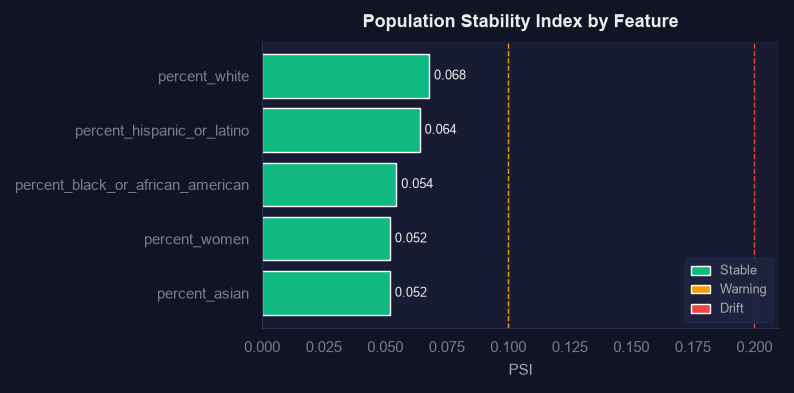

Q3：2021–2023 多元變化最顯著的三個產業（emp≥50k）


,entity_path,entity_label,total_change_l1,emp_2023_k,delta_percent_women,delta_percent_white,delta_percent_black_or_african_american,delta_percent_asian,delta_percent_hispanic_or_latino
144,Manufacturing > Nondurable goods manufacturing...,"Bakeries and tortilla manufacturing, except re...",0.497,208.0,0.086,-0.181,0.173,-0.001,-0.056
50,Manufacturing > Durable goods manufacturing > ...,Commercial and service industry machinery manu...,0.481,75.0,-0.125,0.170,-0.068,-0.058,0.060
266,Wholesale and retail trade > Wholesale trade >...,Furniture and home furnishing merchant wholesa...,0.442,72.0,-0.176,-0.098,0.008,0.084,-0.076


In [10]:
g.use("featured")
panel = g.df[g.df["year"].isin([2021, 2023])].copy()
panel = panel.drop_duplicates(subset=["entity_path", "year"])
g.snapshot("panel_2123", panel, from_stage="featured")

p21 = panel[panel["year"] == 2021]
p23 = panel[panel["year"] == 2023]
shift = g.prep.variate_shift(p23, reference_df=p21, features=DEMO_COLS)
shift.summary()
shift.plot(top_n=10)

# 業務 Top 3：逐 entity L1 delta
p21i = p21.set_index("entity_path")
p23i = p23.set_index("entity_path")
common = p21i.index.intersection(p23i.index)
rows = []
for path in common:
    r21, r23 = p21i.loc[path], p23i.loc[path]
    emp = r23["total_employed_in_thousands"]
    if pd.isna(emp) or emp < 50:
        continue
    delta = sum(abs(r23[c] - r21[c]) for c in DEMO_COLS)
    rows.append({
        "entity_path": path,
        "entity_label": r23["entity_label"],
        "total_change_l1": delta,
        "emp_2023_k": emp,
        **{f"delta_{c}": r23[c] - r21[c] for c in DEMO_COLS},
    })
q3 = pd.DataFrame(rows).sort_values("total_change_l1", ascending=False).head(3).round(3)
print("Q3：2021–2023 多元變化最顯著的三個產業（emp≥50k）")
display(q3)


### Q4：單一族群主導的行業


In [ ]:
g.use("rank_base")
df = g.df.copy()
race_labels = {
    "percent_white": "White",
    "percent_black_or_african_american": "Black/African American",
    "percent_asian": "Asian",
    "percent_hispanic_or_latino": "Hispanic/Latino",
}
df["dominant_race_col"] = df[RACE_COLS].idxmax(axis=1)
df["dominant_race_share"] = df.apply(lambda r: r[r["dominant_race_col"]], axis=1)
df["dominant_race"] = df["dominant_race_col"].map(race_labels)
g.snapshot("rank_dominant", df, from_stage="rank_base")

q4 = (
    df.sort_values("dominant_race_share", ascending=False)
    .head(10)[[
        "entity_label", "dominant_race", "dominant_race_share",
        "race_hhi", "total_employed_in_thousands",
    ]]
    .assign(dominant_pct=lambda d: (d["dominant_race_share"] * 100).round(1))
)
print("Q4：單一族群主導程度最高的行業（Top 10，emp≥100k）")
display(q4)

g.snapshot("q4", q4)
g.use('q4')
g.viz.hist("dominant_race_share")


Q4：單一族群主導程度最高的行業（Top 10，emp≥100k）


,entity_label,dominant_race,dominant_race_share,race_hhi,total_employed_in_thousands,dominant_pct
1020,Lawn and garden equipment and supplies stores,White,0.951,0.809159,271.0,95.1
143,Crop production,White,0.946,0.606197,1222.0,94.6
1044,Other motor vehicle dealers,White,0.934,0.707170,175.0,93.4
19,"Agriculture, forestry, fishing, and hunting",White,0.926,0.619211,2264.0,92.6
353,Sawmills and wood preservation,White,0.919,0.701703,115.0,91.9
99,Animal production and aquaculture,White,0.916,0.632692,705.0,91.6
1227,"Machinery, equipment, and supplies merchant wh...",White,0.915,0.690462,326.0,91.5
189,Agricultural implement manufacturing,White,0.914,0.727244,148.0,91.4
185,Furniture and related product manufacturing,White,0.907,0.618635,376.0,90.7
272,"Machine shops; turned product; screw, nut, and...",White,0.898,0.684766,255.0,89.8


【dominant_race_share】統計量（已去除NA，clip於[0.01, 0.99]分位數之間）:


,count,mean,std,min,1%,25%,50%,75%,99%,max
dominant_race_share,10,1,0,1,1,1,1,1,1,1


### Q5：種族多樣性最高 vs 產業規模


In [12]:
g.use("rank_dominant")
q5 = (
    g.df.sort_values("race_diversity", ascending=False)
    .head(10)[[
        "entity_label", "race_diversity", "race_hhi",
        "percent_white", "percent_black_or_african_american",
        "percent_asian", "percent_hispanic_or_latino",
        "total_employed_in_thousands",
    ]]
)
print("Q5：種族多樣性最高（1−HHI）的產業 Top 10")
display(q5.round(3))

g.viz.scatter("total_employed_in_thousands", "race_diversity")
print(
    "Pearson（多樣性 vs log 規模）：",
    f"{g.df['race_diversity'].corr(np.log1p(g.df['total_employed_in_thousands'])):.3f}",
)


Q5：種族多樣性最高（1−HHI）的產業 Top 10


,entity_label,race_diversity,race_hhi,percent_white,percent_black_or_african_american,percent_asian,percent_hispanic_or_latino,total_employed_in_thousands
1136,Taxi and limousine service,0.693,0.307,0.541,0.253,0.170,0.233,602.0
974,Electronic shopping and mail-order houses,0.657,0.343,0.609,0.200,0.152,0.231,824.0
823,Nail salons and other personal care services,0.651,0.349,0.499,0.063,0.390,0.157,625.0
802,Barber shops,0.650,0.350,0.642,0.299,0.033,0.406,164.0
815,Drycleaning and laundry services,0.644,0.356,0.681,0.146,0.155,0.351,232.0
935,Automotive equipment rental and leasing,0.638,0.362,0.577,0.271,0.077,0.185,180.0
628,Animal slaughtering and processing,0.634,0.366,0.684,0.210,0.068,0.387,434.0
643,"Bakeries and tortilla manufacturing, except re...",0.634,0.366,0.662,0.239,0.056,0.332,208.0
1109,Bus service and urban transit,0.628,0.372,0.580,0.342,0.036,0.192,457.0
457,Home health care services,0.628,0.372,0.623,0.264,0.080,0.195,1387.0


Pearson（多樣性 vs log 規模）： 0.261


## 7. Cache + Lineage 總覽

將 cluster 結果 persist 到 local warehouse；檢視 medallion catalog 與 lineage（含 insights probe 節點）。


In [13]:
g.use("clustered")

g.warehouse.persist(str(WAREHOUSE))
print(f"Persisted warehouse → {WAREHOUSE}")
display(g.warehouse.catalog())
g.warehouse.visualize()

display(g.stages)
print(g.lineage.to_frame().head(12))
g.visualize()


Persisted warehouse → .warehouse\google


,name,layer,shape,parent,inputs,source_path,source
0,raw,None,"(1272, 11)",None,None,None,internal
1,prepared,None,"(1268, 13)",raw,None,None,pipe
2,featured,None,"(1268, 20)",prepared,None,None,pipe
3,snapshot_2023,None,"(317, 20)",featured,None,None,pipe
4,cluster_base,None,"(282, 20)",snapshot_2023,None,None,manual
5,_probe_kmeans_clusters,None,"(282, 21)",cluster_base,None,None,insights
6,clustered,None,"(282, 21)",cluster_base,None,None,insights
7,top25,None,"(25, 21)",clustered,None,None,manual
8,top25_long,None,"(125, 3)",top25,None,None,manual
9,rank_base,None,"(234, 20)",snapshot_2023,None,None,manual


,name,shape,parent,layer,inputs,source_path,cols_added,cols_removed,rows_diff,rows_diff_pct,source,cols_read
0,raw,"(1272, 11)",None,None,None,None,[],[],NaN,NaN,internal,None
1,prepared,"(1268, 13)",raw,None,None,None,"[entity_label, entity_path]",[],-4.0,-0.3,pipe,[]
2,featured,"(1268, 20)",prepared,None,None,None,"[gender_imbalance, percent_asian_norm, percent...",[],0.0,0.0,pipe,[]
3,snapshot_2023,"(317, 20)",featured,None,None,None,[],[],-951.0,-75.0,pipe,[year]
4,cluster_base,"(282, 20)",snapshot_2023,None,None,None,[],[],-35.0,-11.0,manual,None
5,_probe_kmeans_clusters,"(282, 21)",cluster_base,None,None,None,[kmeans_cluster],[],0.0,0.0,insights,[]
6,clustered,"(282, 21)",cluster_base,None,None,None,[kmeans_cluster],[],0.0,0.0,insights,[]
7,top25,"(25, 21)",clustered,None,None,None,[],[],-257.0,-91.1,manual,None
8,top25_long,"(125, 3)",top25,None,None,None,"[feature, share]","[entity_path, gender_imbalance, industry, indu...",100.0,400.0,manual,None
9,rank_base,"(234, 20)",snapshot_2023,None,None,None,[],[],-83.0,-26.2,manual,None


                                   feature   kind                    step  \
0                             entity_label  added                prepared   
1                              entity_path  added                prepared   
2                         gender_imbalance  added                featured   
3                       percent_asian_norm  added                featured   
4   percent_black_or_african_american_norm  added                featured   
5          percent_hispanic_or_latino_norm  added                featured   
6                       percent_white_norm  added                featured   
7                           race_diversity  added                featured   
8                                 race_hhi  added                featured   
9                           kmeans_cluster  added  _probe_kmeans_clusters   
10                          kmeans_cluster  added               clustered   
11                                 feature  added              top25_long   

## 8. 結論（對照六題）

| # | 結論摘要 |
|---|----------|
| Q1 | KMeans 集群將性別+種族結構相近的產業聚在一起；可看 `q1` 表的 `top_entities` |
| Q2 | 性別失衡 Top 3 由 `gender_imbalance` 排序；scatter 顯示規模與失衡未必負相關 |
| Q3 | `variate_shift` 標記 2021→2023 demographics 漂移；L1 Top 3 為變化最劇產業 |
| Q4 | `dominant_race_share` 接近 1 表示單一族群高度主導 |
| Q5 | 高 `race_diversity` 產業多為多族群混合；與 log 規模相關性通常偏弱 |
| Q1/Q6 | `g.insights.segment()` + `commit()` 產業分群；PCA 見 `plot_embedding()` |

**方法**：全程 `GAMMA_DNA` v2 — `g.pipe` lineage、`g.warehouse.persist`、`g.insights` 聚類/PCA、`g.prep.variate_shift`，無 legacy v1。
